# Inter-Annotator Agreement & Balanced Accuracy Bound

Four human annotators (E, F, G, H) independently labelled a subset of ants/v3 videos.
We measure how much they agree, and use that as a **hard upper bound on balanced accuracy**:
a model evaluated against human annotations cannot exceed the agreement between humans.

The bound is the **worst-case pairwise IA-BA** — the minimum agreement across annotator pairs,
taken as min(BA(A→B), BA(B→A)) to be conservative when neither annotator is ground truth.

In [1]:
import sys, yaml
from pathlib import Path
from itertools import combinations
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Make src importable
ROOT = Path('../../').resolve()
sys.path.insert(0, str(ROOT / 'src'))

from dataset.get_annotations import AnnotationExtractor
from utils import noise_bound, mixed_ba_bound
from visualize import plot_iaba_heatmap, plot_disagreement_temporal

print('ROOT:', ROOT)

ROOT: /nfs/scistore19/locatgrp/rcadei/artificial-causal-inference


In [2]:
# ── USER CONFIGURATION ──────────────────────────────────────────────────────

OUTCOMES_TO_ANALYZE  = ['Y2F', 'B2F']   # None = all v3 outcomes
INCLUDE_AVG_OUTCOME  = True              # add AVG(Y2F,B2F) summary row
N_DISAGREE_EXAMPLES  = 10               # disagreement frames to show per outcome

RESULTS_DIR = Path('results')
RESULTS_DIR.mkdir(exist_ok=True)

FRAME_ROOT = ROOT / 'dataset' / 'ants' / 'v3' / 'frames' / 'full'
# ─────────────────────────────────────────────────────────────────────────────

## 1. Load v3 config and build extractor

In [3]:
CONFIG_PATH = ROOT / 'configs' / 'dataset' / 'ants' / 'v3.yaml'
with open(CONFIG_PATH) as f:
    cfg = yaml.safe_load(f)

ALL_OUTCOMES = cfg['outcomes']        # ['Y2F', 'B2F', 'FOL', 'YOL', 'BOL']
OUTCOME_MAP  = cfg['outcome_mapping']

# Filter to selected outcomes
OUTCOMES = (
    [o for o in ALL_OUTCOMES if o in OUTCOMES_TO_ANALYZE]
    if OUTCOMES_TO_ANALYZE is not None
    else list(ALL_OUTCOMES)
)

extractor = AnnotationExtractor(OUTCOME_MAP)

# v3 metadata (from data/ants/v3/observations/metadata.json)
SOURCE_FPS = 30.0
TARGET_FPS =  5.0
FPS_RATIO  = SOURCE_FPS / TARGET_FPS   # 6

print('All v3 outcomes:', ALL_OUTCOMES)
print('Analysing:      ', OUTCOMES)
print(f'FPS: {SOURCE_FPS} → {TARGET_FPS} (ratio {FPS_RATIO})')

All v3 outcomes: ['Y2F', 'B2F', 'FOL', 'YOL', 'BOL']
Analysing:       ['Y2F', 'B2F']
FPS: 30.0 → 5.0 (ratio 6.0)


## 2. Discover videos annotated by multiple annotators

In [4]:
ANNOT_ROOT = Path('annotations')
annotators = sorted(p.name for p in ANNOT_ROOT.iterdir() if p.is_dir())
print('Annotators:', annotators)

stems_by_annotator = {
    a: {p.stem for p in (ANNOT_ROOT / a).glob('*.csv')}
    for a in annotators
}

all_stems = set.union(*stems_by_annotator.values())

multi_annotated = {
    stem: [a for a in annotators if stem in stems_by_annotator[a]]
    for stem in sorted(all_stems)
    if sum(stem in stems_by_annotator[a] for a in annotators) >= 2
}

print(f'\nVideos with >=2 annotators: {len(multi_annotated)}')
for stem, anns in multi_annotated.items():
    print(f'  {stem}: {anns}')

Annotators: ['E', 'F', 'G', 'H']

Videos with >=2 annotators: 22
  3_10_2: ['E', 'F', 'H']
  3_11_8: ['E', 'F', 'G', 'H']
  3_13_5: ['E', 'G']
  3_13_6: ['E', 'G']
  3_13_7: ['E', 'H']
  3_17_3: ['E', 'G']
  3_17_7: ['E', 'F', 'G', 'H']
  3_18_1: ['E', 'H']
  3_20_2: ['E', 'H']
  3_20_8: ['E', 'H']
  3_21_1: ['E', 'G']
  3_23_3: ['E', 'G']
  3_25_1: ['E', 'G']
  3_25_2: ['E', 'G']
  3_3_5: ['E', 'H']
  3_3_7: ['E', 'H']
  3_4_1: ['E', 'H']
  3_6_1: ['E', 'G']
  3_6_2: ['E', 'F', 'G', 'H']
  3_6_9: ['E', 'H']
  3_7_1: ['E', 'F', 'H']
  3_8_8: ['E', 'G']


## 3. Load experiment metadata for start_frame offsets

In [5]:
exp_df = pd.read_csv(ROOT / 'data' / 'ants' / 'v3' / 'experiment.csv').set_index('observation_id')

def get_frame_info(obs_id):
    """Return (n_target_frames, start_frame_offset)."""
    if obs_id in exp_df.index:
        row = exp_df.loc[obs_id]
        start = int(row.get('start_frame', 0) or 0)
        end   = int(row.get('end_frame',   18000) or 18000)
        return int((end - start) / FPS_RATIO), start
    return 3000, 0  # default: 10 min at 30fps -> 3000 frames at 5fps

print(get_frame_info('3_10_2'))  # expect (3000, 0)

(3000, 0)


## 4. Extract per-frame labels for every annotator × video pair

In [6]:
labels = defaultdict(dict)  # labels[video_stem][annotator] -> DataFrame indexed by frame_idx

for stem, anns in multi_annotated.items():
    n_frames, offset = get_frame_info(stem)
    obs_cfg = {
        **cfg,
        'frame_count':        n_frames,
        'source_fps':         SOURCE_FPS,
        'target_fps':         TARGET_FPS,
        'start_frame_offset': offset,
    }
    for ann in anns:
        ann_file = ANNOT_ROOT / ann / f'{stem}.csv'
        try:
            df = extractor.extract_labels(ann_file, stem, obs_cfg)
            labels[stem][ann] = df.set_index('frame_idx')
        except Exception as e:
            print(f'  [WARN] {stem}/{ann}: {e}')

print(f'Loaded labels for {len(labels)} videos')
for stem, adict in labels.items():
    nf = next(iter(adict.values())).shape[0]
    print(f'  {stem}: {list(adict.keys())}, {nf} frames')

Loaded labels for 22 videos
  3_10_2: ['E', 'F', 'H'], 3000 frames
  3_11_8: ['E', 'F', 'G', 'H'], 3000 frames
  3_13_5: ['E', 'G'], 3000 frames
  3_13_6: ['E', 'G'], 3000 frames
  3_13_7: ['E', 'H'], 3000 frames
  3_17_3: ['E', 'G'], 3000 frames
  3_17_7: ['E', 'F', 'G', 'H'], 3000 frames
  3_18_1: ['E', 'H'], 3000 frames
  3_20_2: ['E', 'H'], 3000 frames
  3_20_8: ['E', 'H'], 3000 frames
  3_21_1: ['E', 'G'], 3000 frames
  3_23_3: ['E', 'G'], 3000 frames
  3_25_1: ['E', 'G'], 3000 frames
  3_25_2: ['E', 'G'], 3000 frames
  3_3_5: ['E', 'H'], 3000 frames
  3_3_7: ['E', 'H'], 3000 frames
  3_4_1: ['E', 'H'], 3000 frames
  3_6_1: ['E', 'G'], 3000 frames
  3_6_2: ['E', 'F', 'G', 'H'], 3000 frames
  3_6_9: ['E', 'H'], 3000 frames
  3_7_1: ['E', 'F', 'H'], 3000 frames
  3_8_8: ['E', 'G'], 3000 frames


## 5. Pairwise IA-BA

For each pair of annotators sharing a video, per outcome:
- **IA-BA** = min(BA(A→B), BA(B→A)) — conservative because BA is not symmetric when
  annotators have different positive rates (see asymmetry printout below)
- **Cohen's κ** — chance-corrected, symmetric by construction

In [7]:
records = []

for stem, adict in labels.items():
    for a1, a2 in combinations(sorted(adict.keys()), 2):
        df1, df2 = adict[a1], adict[a2]
        idx = df1.index.intersection(df2.index)

        for out in OUTCOMES:
            col = f'Y_{out}'
            if col not in df1.columns or col not in df2.columns:
                continue
            y1 = df1.loc[idx, col].values.astype(int)
            y2 = df2.loc[idx, col].values.astype(int)

            tp = ((y1 == 1) & (y2 == 1)).sum()
            tn = ((y1 == 0) & (y2 == 0)).sum()
            n1p, n1n = (y1 == 1).sum(), (y1 == 0).sum()
            n2p, n2n = (y2 == 1).sum(), (y2 == 0).sum()

            ba_12 = np.nanmean([tp / n1p if n1p > 0 else np.nan,
                                tn / n1n if n1n > 0 else np.nan])
            ba_21 = np.nanmean([tp / n2p if n2p > 0 else np.nan,
                                tn / n2n if n2n > 0 else np.nan])
            ia_ba = np.nanmin([ba_12, ba_21])   # conservative

            agree = (y1 == y2).mean()
            p_e   = (y1.mean()*y2.mean() + (1-y1.mean())*(1-y2.mean()))
            kappa = (agree - p_e) / (1 - p_e) if (1 - p_e) > 0 else np.nan

            # class-stratified disagreement (used for noise-model bound)
            maj = ((y1 + y2) >= 1).astype(int)
            p1  = (y1[maj==1] != y2[maj==1]).mean() if (maj==1).any() else np.nan
            p0  = (y1[maj==0] != y2[maj==0]).mean() if (maj==0).any() else np.nan

            records.append(dict(
                video=stem, ann_a=a1, ann_b=a2, outcome=out,
                ia_ba=ia_ba, ba_12=ba_12, ba_21=ba_21,
                disagree_pos=p1, disagree_neg=p0, kappa=kappa,
            ))

pairs_df = pd.DataFrame(records)
pairs_df['pair'] = pairs_df['ann_a'] + '-' + pairs_df['ann_b']

print('Asymmetry |BA(A→B) − BA(B→A)| mean over pairs:')
asym = (pairs_df['ba_12'] - pairs_df['ba_21']).abs()
print(pairs_df.assign(asym=asym).groupby('outcome')['asym'].mean().reindex(OUTCOMES).round(4).to_string())
print(f'\n{len(pairs_df)} pair × outcome records')
pairs_df[['video','pair','outcome','ia_ba','ba_12','ba_21','kappa']].head(6)

Asymmetry |BA(A→B) − BA(B→A)| mean over pairs:
outcome
Y2F    0.0656
B2F    0.0091

82 pair × outcome records


,video,pair,outcome,ia_ba,ba_12,ba_21,kappa
0,3_10_2,E-F,Y2F,0.991781,0.992603,0.991781,0.984381
1,3_10_2,E-F,B2F,0.971537,0.971537,0.973776,0.945303
2,3_10_2,E-H,Y2F,0.989479,0.989479,0.995769,0.985144
3,3_10_2,E-H,B2F,0.974063,0.974063,0.983262,0.957154
4,3_10_2,F-H,Y2F,0.982153,0.982153,0.989165,0.971186
5,3_10_2,F-H,B2F,0.978154,0.978154,0.985129,0.963185


## 6. Aggregate statistics per outcome

In [8]:
agg = (
    pairs_df.groupby('outcome')
    .agg(
        ia_ba_mean  =('ia_ba',        'mean'),
        ia_ba_min   =('ia_ba',        'min'),
        ia_ba_max   =('ia_ba',        'max'),
        kappa_mean  =('kappa',        'mean'),
        disagree_pos=('disagree_pos', 'mean'),
    )
    .reindex(OUTCOMES)
)
agg['noise_bound'] = agg['disagree_pos'].apply(noise_bound)

# Worst-case pair: each pair averaged over its shared videos, then min over pairs
worst_pair = (
    pairs_df.groupby(['outcome', 'pair'])['ia_ba'].mean()
    .groupby('outcome').min()
    .reindex(OUTCOMES)
)
agg['worst_pair_ba'] = worst_pair

# AVG row: mean of Y2F and B2F, matching ppci multilabel reporting
if INCLUDE_AVG_OUTCOME and {'Y2F', 'B2F'}.issubset(agg.index):
    avg_row = agg.loc[['Y2F', 'B2F']].mean()
    avg_row.name = 'AVG(Y2F,B2F)'
    agg = pd.concat([agg, avg_row.to_frame().T])

agg[['worst_pair_ba', 'noise_bound', 'ia_ba_mean', 'ia_ba_min', 'ia_ba_max', 'kappa_mean']].round(3)

,worst_pair_ba,noise_bound,ia_ba_mean,ia_ba_min,ia_ba_max,kappa_mean
Y2F,0.798,0.902,0.925,0.500,1.0,0.842
B2F,0.951,0.971,0.974,0.874,1.0,0.951
"AVG(Y2F,B2F)",0.875,0.937,0.950,0.687,1.0,0.896


## 7. Visualisations

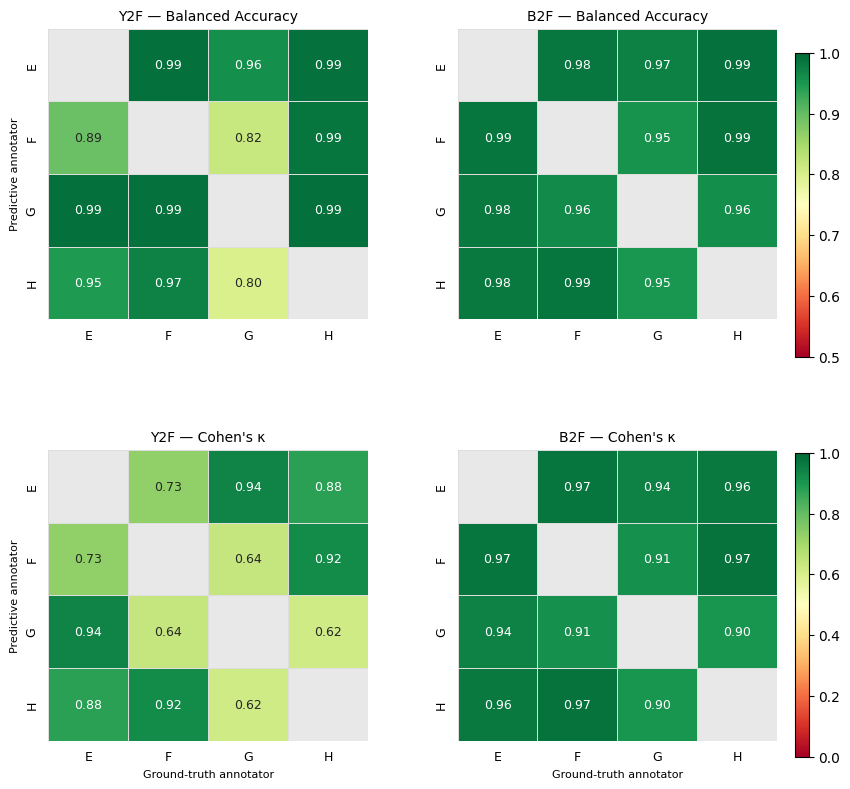

In [9]:
fig = plot_iaba_heatmap(
    pairs_df, OUTCOMES,
    save_path=RESULTS_DIR / 'iaba_heatmap.pdf',
)
plt.show()

## 8. Why is Y2F harder to annotate than B2F?

From the results: Y2F disagreement on positive frames (~18%) is roughly 3× higher than B2F (~6%).

- **Blue is a more salient marking.** Ant bodies are naturally yellow/amber/brown,
  so a yellow dot blends with the ant's own coloration and with warm background tones.
  Blue is a completely unnatural color in this context and stands out immediately
  against both the ant body and the substrate — making the blue-marked nurse easy to
  track even in degraded conditions.

- **Short bouts and boundary ambiguity.** Both Y2F and B2F suffer from missed detections
  at the onset and offset of grooming events: a few frames where the ant is *approaching*
  or *withdrawing* can look like grooming to one annotator and not another.
  This effect is amplified for Y2F because the yellow ant itself is harder to localize,
  so the perceived start/end of contact is less crisp.

The disagreement frames below show the worst-disagreeing annotator pair for each outcome,
illustrating the visual ambiguity directly.

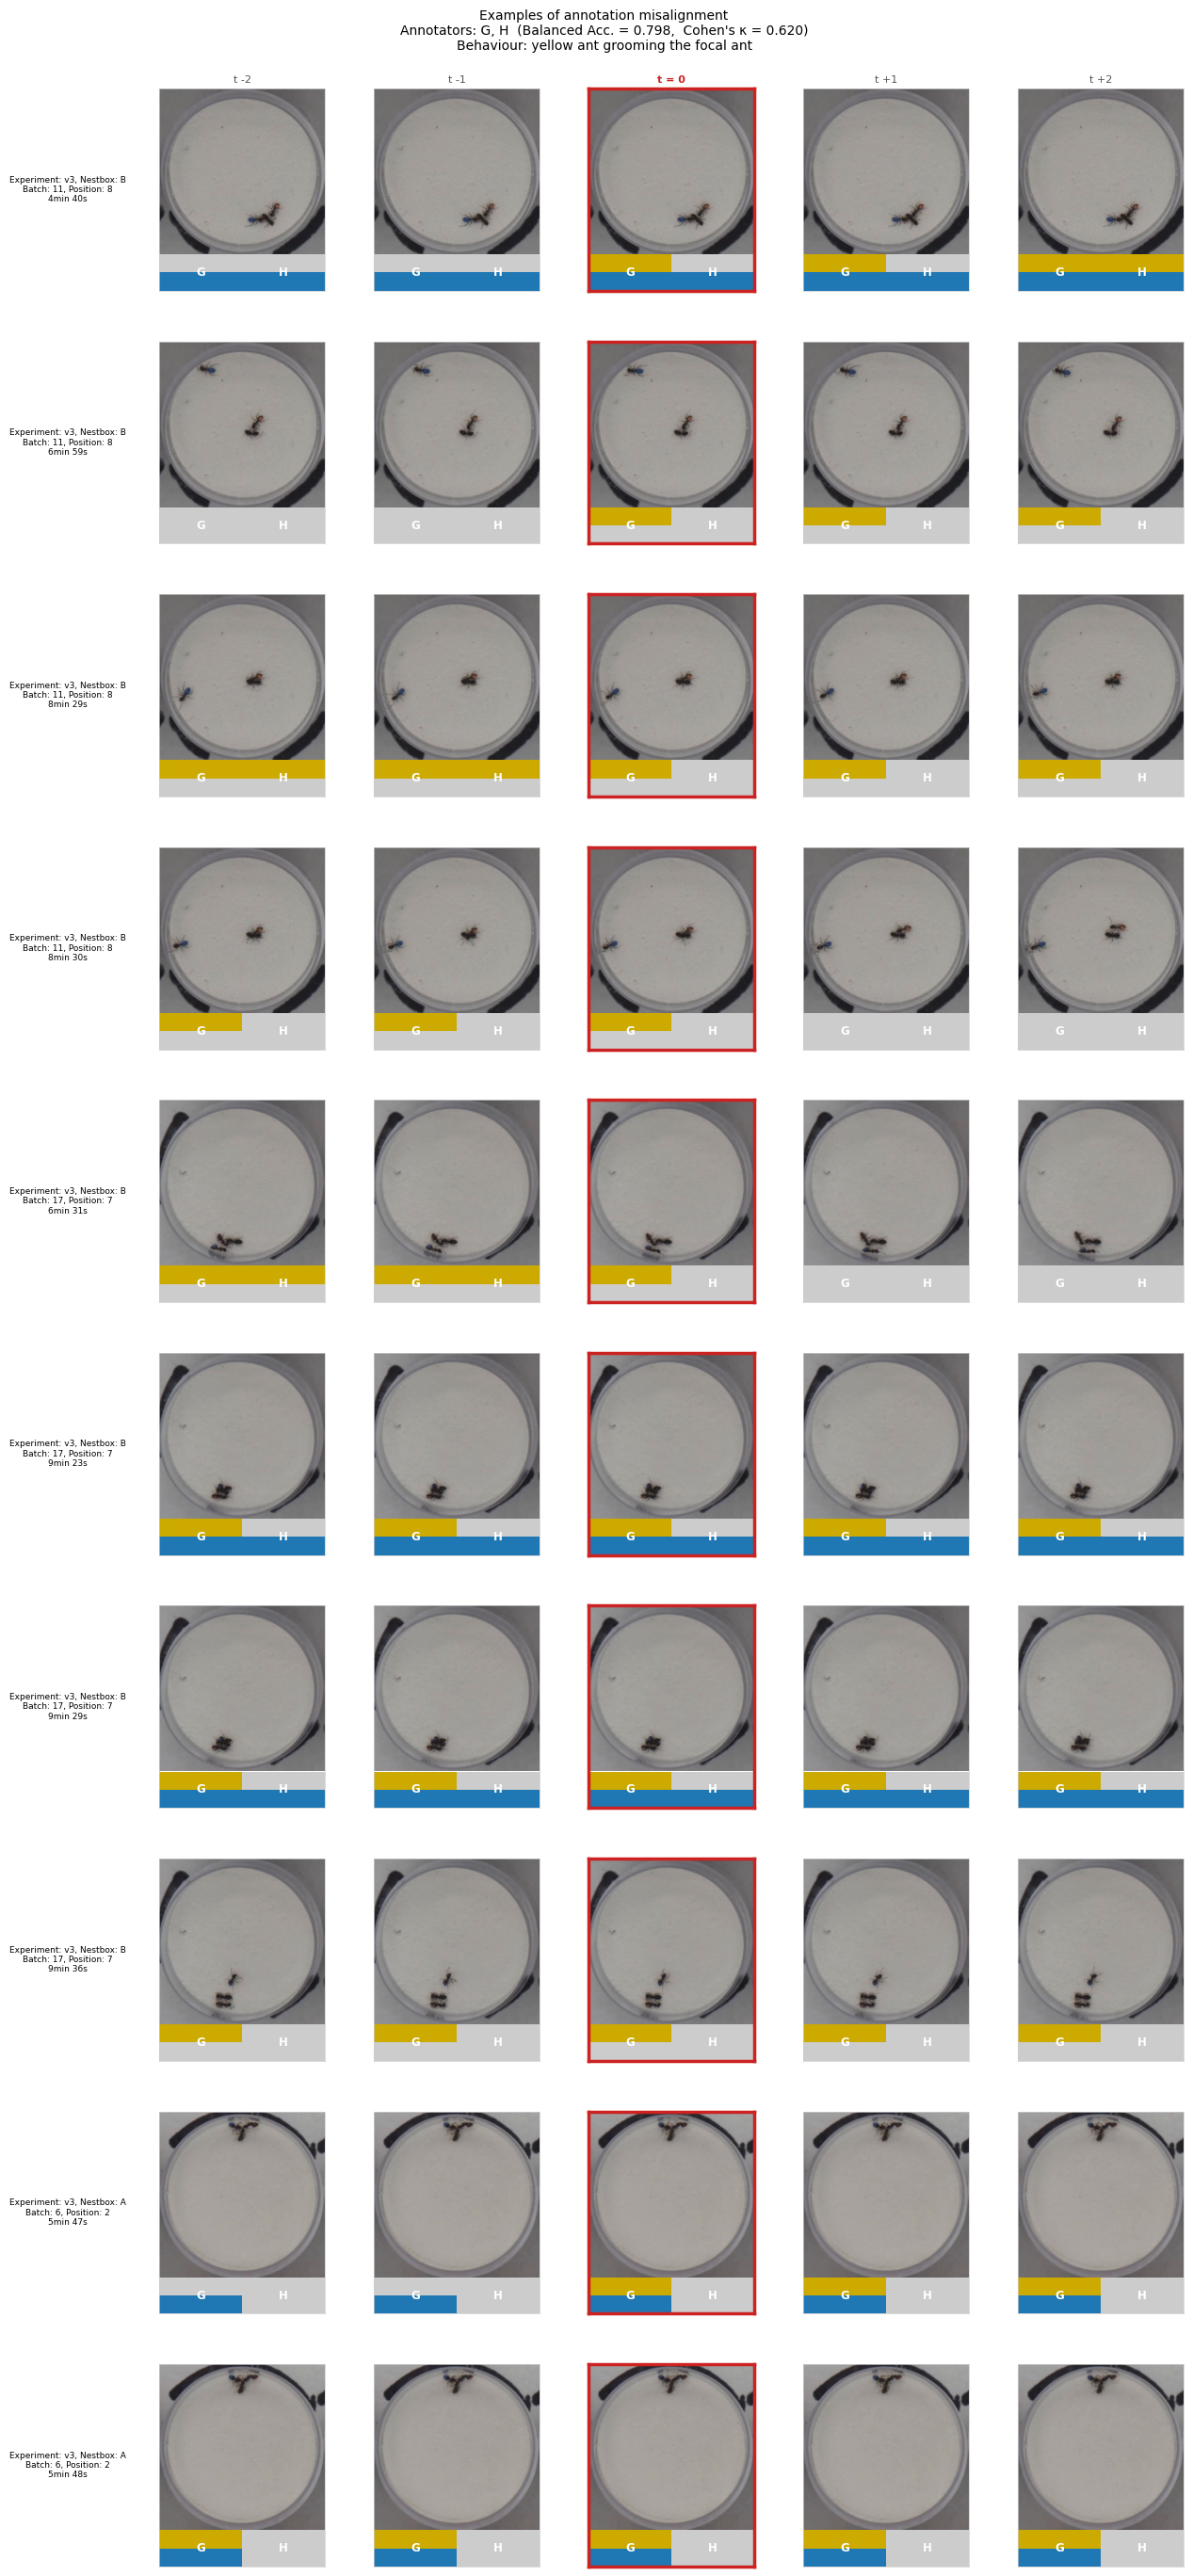

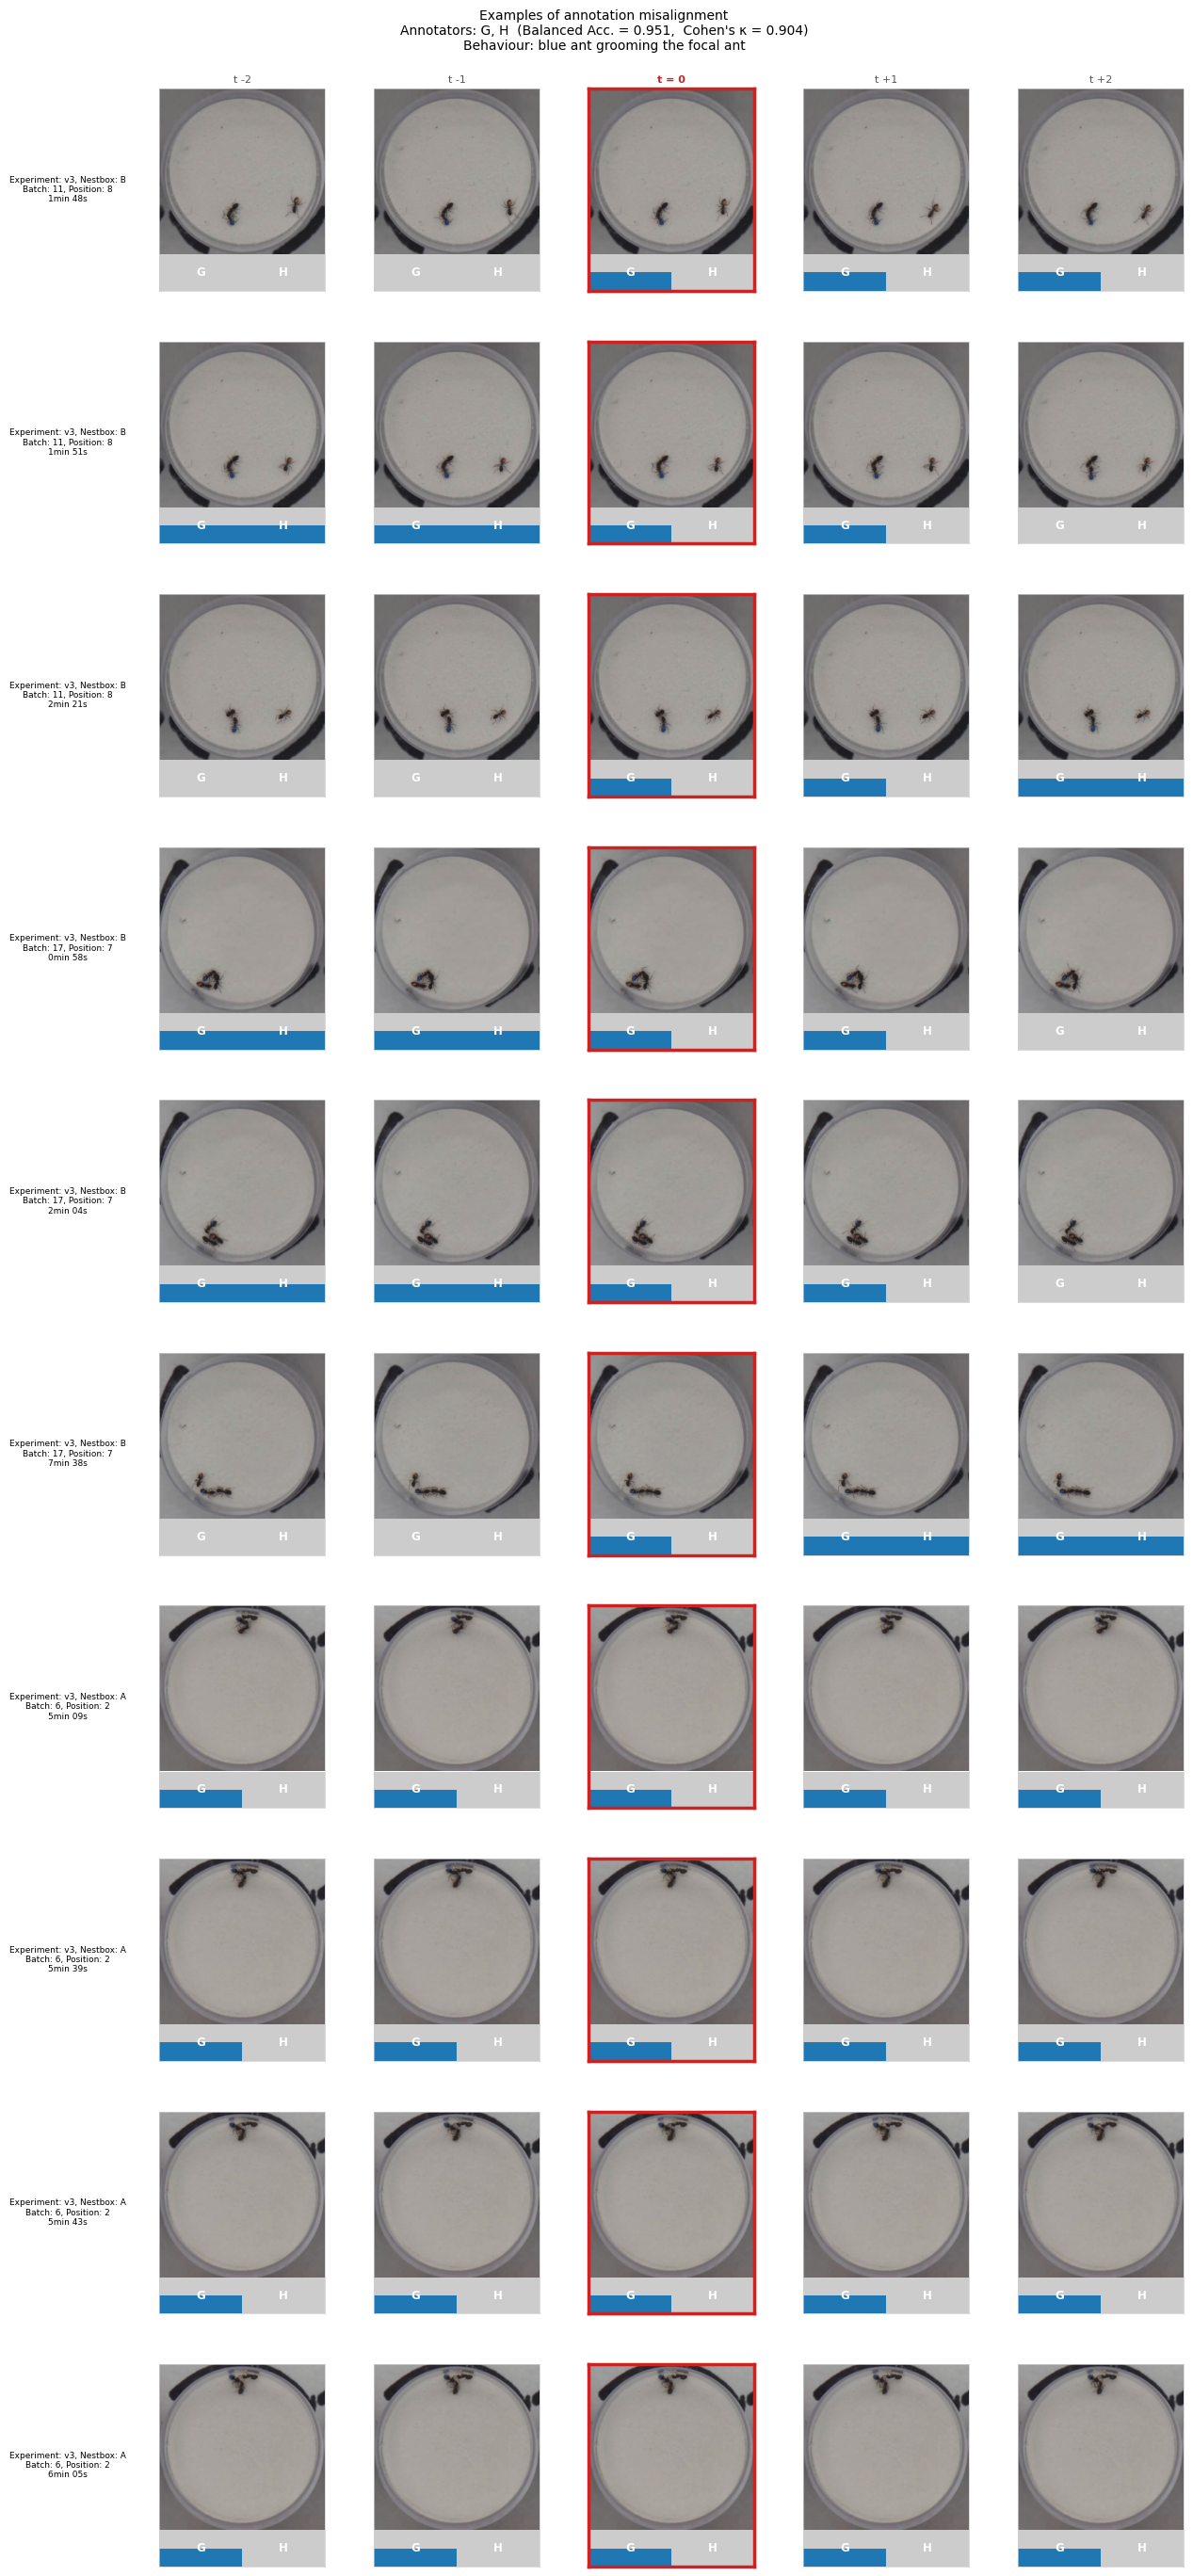

In [10]:
for viz_out in OUTCOMES:
    fig = plot_disagreement_temporal(
        labels, pairs_df, FRAME_ROOT,
        outcome=viz_out,
        k=N_DISAGREE_EXAMPLES,
        exp_df=exp_df,
        save_path=RESULTS_DIR / f'disagreement_{viz_out}.pdf',
    )
    if fig is not None:
        plt.show()

## 9. The bound

**`worst_pair_ba` is the headline number**: the lowest average IA-BA across all annotator pairs.
No model evaluated against human labels can exceed it.

| Quantity | How to read it |
|---|---|
| `worst_pair_ba` | **Hard upper bound** — worst human pair sets the ceiling |
| `noise_bound` | Analytical bound from noise model: `1 − ε₁/2` (since ε₀≈0) |
| `ia_ba_mean` | Typical agreement; a model at average human level would reach this |
| `kappa_mean` | Chance-corrected cross-check; κ > 0.6 = substantial |

**Why BA is not symmetric.** Sensitivity = TP/n⁺ uses the 'truth' annotator's count as
denominator, so BA(A→B) ≠ BA(B→A) when positive rates differ.
Taking the min over both directions is the conservative choice.

**All noise is in positives.** Annotators agree perfectly on 'no grooming' frames (ε₀≈0).
Disagreement is entirely about *when* grooming occurs, not the background state.

**AVG(Y2F, B2F)** averages the two bounds, matching ppci multilabel reporting
(`task: multilabel`, mean over outcomes) so the bound is directly comparable to model scores.

### Mixed-annotator dataset

In v3 each video has one annotator; the full dataset mixes several.
When train and test are split by video the effective bound is weighted by annotator frequencies:

$$\text{BA}^*_{\text{mix}} = \sum_i f_i^2 \cdot 1 + \sum_{i \neq j} f_i f_j \cdot \text{IA-BA}(i,j)$$

Same-annotator pairs (weight $f_i^2$) are unconstrained; cross-annotator pairs are
capped by the measured IA-BA. Computed in the next cell.

In [11]:
# --- Annotator distribution in the full v3 dataset ---
ann_counts = exp_df['annotator'].value_counts()
ann_fracs  = ann_counts / ann_counts.sum()
print('Annotator distribution in v3:')
print(ann_fracs.to_string())

known_annotators = sorted(stems_by_annotator.keys())  # ['E', 'F', 'G', 'H']

# --- Pairwise IA-BA matrix per outcome (mean over shared videos) ---
ia_ba_matrix = {}
for out in OUTCOMES:
    sub = pairs_df[pairs_df.outcome == out]
    mat = pd.DataFrame(np.eye(len(known_annotators)),
                       index=known_annotators, columns=known_annotators)
    pair_means = sub.groupby(['ann_a', 'ann_b'])['ia_ba'].mean()
    for (a1, a2), v in pair_means.items():
        if not np.isnan(v):
            mat.loc[a1, a2] = v
            mat.loc[a2, a1] = v
    ia_ba_matrix[out] = mat

# --- Weighted BA bound for the mixed-annotator dataset ---
# BA*_mix = Σ_i f_i^2 * 1  +  Σ_{i≠j} f_i*f_j * IA-BA(i,j)
# Same-annotator train/test pairs are not noise-limited (contribute 1).
# Cross-annotator pairs are capped by the measured pairwise IA-BA.
def mixed_ba_bound(fracs, mat):
    bound, total_w = 0.0, 0.0
    for i, fi in fracs.items():
        for j, fj in fracs.items():
            if i not in mat.index or j not in mat.columns:
                continue
            w = fi * fj
            bound   += w * (1.0 if i == j else mat.loc[i, j])
            total_w += w
    return bound / total_w if total_w > 0 else float('nan')

rows = []
for out in OUTCOMES:
    mat    = ia_ba_matrix[out]
    common = [a for a in ann_fracs.index if a in mat.index]
    if not common:
        rows.append({'outcome': out, 'BA* mix': float('nan')})
        continue
    sub_fracs = ann_fracs[common]
    sub_fracs = sub_fracs / sub_fracs.sum()
    bound = mixed_ba_bound(sub_fracs, mat)
    rows.append({'outcome': out, 'BA* mix': bound,
                 'IA-BA (mean)': agg.loc[out, 'ia_ba_mean'] if out in agg.index else float('nan'),
                 'BA* (noise model)': agg.loc[out, 'noise_bound'] if out in agg.index else float('nan')})

mix_df = pd.DataFrame(rows).set_index('outcome')
print('\nMixed-annotator BA upper bound per outcome:')
print(mix_df.round(3).to_string())
print('\n(Annotators not in IA-BA sample contribute ceiling=1 — bound is optimistic for those pairs)')
mix_df

Annotator distribution in v3:
annotator
F    0.386792
E    0.325472
G    0.179245
H    0.108491

Mixed-annotator BA upper bound per outcome:
         BA* mix  IA-BA (mean)  BA* (noise model)
outcome                                          
Y2F        0.928         0.925              0.902
B2F        0.981         0.974              0.971

(Annotators not in IA-BA sample contribute ceiling=1 — bound is optimistic for those pairs)


,BA* mix,IA-BA (mean),BA* (noise model)
outcome,,,
Y2F,0.928164,0.92516,0.902459
B2F,0.981445,0.97438,0.970790


In [12]:
summary = agg[['worst_pair_ba', 'noise_bound', 'ia_ba_mean', 'kappa_mean']].copy()
summary.columns = ['BA bound (worst pair)', 'BA bound (noise model)', 'IA-BA mean', 'κ mean']
summary.index.name = 'Outcome'

display(summary.round(3))

print('\n=== Conclusion ===')
for out in list(OUTCOMES) + (['AVG(Y2F,B2F)'] if INCLUDE_AVG_OUTCOME else []):
    if out not in summary.index: continue
    b = summary.loc[out, 'BA bound (worst pair)']
    m = summary.loc[out, 'IA-BA mean']
    label = out if out != 'AVG(Y2F,B2F)' else 'AVG'
    print(f'  {label}: human-level BA from a model evaluated on human annotations is'
          f' at most {b:.3f} (mean pairwise {m:.3f})')

,BA bound (worst pair),BA bound (noise model),IA-BA mean,κ mean
Outcome,,,,
Y2F,0.798,0.902,0.925,0.842
B2F,0.951,0.971,0.974,0.951
"AVG(Y2F,B2F)",0.875,0.937,0.950,0.896



=== Conclusion ===
  Y2F: human-level BA from a model evaluated on human annotations is at most 0.798 (mean pairwise 0.925)
  B2F: human-level BA from a model evaluated on human annotations is at most 0.951 (mean pairwise 0.974)
  AVG: human-level BA from a model evaluated on human annotations is at most 0.875 (mean pairwise 0.950)
